# 測試

In [1]:
# ===================================================
# 🎯 1. 修正版實時推論引擎 (新增 0.5 秒防連發冷卻機制)
# ===================================================
class RealTimeBCIEngine:
    def __init__(self, trained_classifier, subject_scaler, threshold_blink=800):
        self.classifier = trained_classifier
        self.subject_scaler = subject_scaler 
        self.threshold_blink = threshold_blink
        self.fs = Config.SAMPLING_RATE
        
        # 🛡️ 新增：眨眼冷卻機制變數
        self.last_blink_time = -999.0  # 紀錄上一次觸發眨眼的時間
        self.blink_cooldown = 0.5      # 設定冷卻時間為 0.5 秒
        
        from scipy.signal import butter
        nyquist = 0.5 * self.fs
        self.b, self.a = butter(4, [1.0 / nyquist, 40.0 / nyquist], btype='band')

    def _extract_single_feature(self, segment):
        from scipy.signal import welch
        from scipy.stats import kurtosis
        
        freqs, psd = welch(segment, fs=self.fs, nperseg=self.fs)
        
        delta_idx = np.logical_and(freqs >= 1, freqs < 4)
        theta_idx = np.logical_and(freqs >= 4, freqs < 8)
        alpha_idx = np.logical_and(freqs >= 8, freqs < 13)
        beta_idx  = np.logical_and(freqs >= 13, freqs < 30)
        gamma_idx = np.logical_and(freqs >= 30, freqs <= 40)
        
        delta_power = np.sum(psd[delta_idx])
        theta_power = np.sum(psd[theta_idx])
        alpha_power = np.sum(psd[alpha_idx])
        beta_power  = np.sum(psd[beta_idx])
        gamma_power = np.sum(psd[gamma_idx])
        
        total_power = delta_power + theta_power + alpha_power + beta_power + gamma_power + 1e-6
        rel_alpha = alpha_power / total_power
        rel_beta = beta_power / total_power
        theta_beta_ratio = theta_power / (beta_power + 1e-6)
        
        variance = np.var(segment)
        peak_to_peak = np.ptp(segment)
        kurt = kurtosis(segment) 
        
        feature = np.array([
            delta_power, theta_power, alpha_power, beta_power, gamma_power,
            rel_alpha, rel_beta, theta_beta_ratio,
            variance, peak_to_peak, kurt,
        ])
        return feature.reshape(1, -1)

    # 💡 注意：這裡多傳入了一個 current_time_sec 參數，讓引擎知道現在是第幾秒
    def analyze_buffer(self, raw_buffer, current_time_sec):
        required_samples = int(6.0 * self.fs)
        if len(raw_buffer) < required_samples:
            return 0.5, 0, np.array([0.33, 0.33, 0.33])
            
        recent_6s = raw_buffer[-required_samples:]
        
        # 軌道一：高速眨眼偵測 (看最後 0.5 秒)
        blink_samples = int(0.5 * self.fs)
        recent_05s = recent_6s[-blink_samples:]
        
        is_blink = 0
        # 💡 核心邏輯：只有在「現在時間」距離「上次眨眼時間」超過 0.5 秒時，才允許判斷眨眼
        if (current_time_sec - self.last_blink_time) >= self.blink_cooldown:
            if np.ptp(recent_05s) > self.threshold_blink:
                is_blink = 1
                self.last_blink_time = current_time_sec # 更新最後眨眼時間
        
        # 軌道二：慢速專注度預測
        from scipy.signal import filtfilt
        filtered_6s = filtfilt(self.b, self.a, recent_6s)
        features = self._extract_single_feature(filtered_6s)
        
        if self.subject_scaler is not None:
            features = self.subject_scaler.transform(features)
            
        features_scaled = self.classifier.scaler.transform(features)
        
        self.classifier.model.eval()
        X_t = torch.tensor(features_scaled, dtype=torch.float32).to(device)
        
        with torch.no_grad():
            outputs = self.classifier.model(X_t)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
            
        p_relax = probs[0]
        p_focus = probs[1]
        
        if (p_focus + p_relax) == 0:
            focus_ratio = 0.5
        else:
            focus_ratio = p_focus / (p_focus + p_relax)
            
        return focus_ratio, is_blink, probs


# ===================================================
# 🎯 2. 修正版實時模擬器
# ===================================================
def simulate_realtime_probs(trained_classifier, test_subject="S02", task_id="2"):
    print(f"\n⚙️ [系統校準中] 正在為 {test_subject} 建立實時阻抗校準曲線...")
    
    subject_folder = os.path.join(Config.DATASET_PATH, test_subject)
    all_files = glob.glob(os.path.join(subject_folder, "*.txt"))
    
    segment_length_samples = int(Config.SEGMENT_LENGTH * Config.SAMPLING_RATE)
    overlap_samples = int(segment_length_samples * Config.OVERLAP_RATIO)
    
    temp_engine = RealTimeBCIEngine(trained_classifier, subject_scaler=None)
    calibration_features = []
    
    for f in all_files:
        try:
            data = np.loadtxt(f)
            start = 0
            step = segment_length_samples - overlap_samples
            while start + segment_length_samples <= len(data):
                seg = data[start:start + segment_length_samples]
                feat = temp_engine._extract_single_feature(seg)
                calibration_features.append(feat[0])
                start += step
        except:
            pass
            
    sub_scaler = StandardScaler()
    sub_scaler.fit(np.array(calibration_features))
    print(f"✅ 校準完成！已拉平 {test_subject} 的基準線電壓。")
    
    engine = RealTimeBCIEngine(trained_classifier, sub_scaler, threshold_blink=800)
    
    search_pattern = os.path.join(subject_folder, f"{test_subject}_{task_id}_*.txt")
    files = glob.glob(search_pattern)
    if not files:
        print(f"❌ 找不到 {test_subject} 的任務檔案")
        return
        
    raw_data = np.loadtxt(files[0])
    fs = Config.SAMPLING_RATE
    window_size = int(6.0 * fs)     
    step_size = int(0.1 * fs)       
    
    print("=" * 95)
    print(f"{'時間 (Time)':<12}{'放鬆機率 (Relax)':<12}{'專注機率 (Focus)':<12}{'眨眼機率 (Blink)':<12}{'最終專注指數':<12}{'事件狀態'}")
    print("=" * 95)
    
    current_end = window_size
    smooth_focus = 0.5 
    
    while current_end <= len(raw_data):
        current_buffer = raw_data[current_end - window_size : current_end]
        
        # 💡 將當前遊戲時間 (current_time_sec) 提前計算，並傳遞給引擎
        current_time_sec = current_end / fs
        raw_focus_ratio, is_blink, raw_probs = engine.analyze_buffer(current_buffer, current_time_sec)
        
        # 指數平滑保留 80% 歷史狀態，讓準星移動更柔和
        smooth_focus = (0.8 * smooth_focus) + (0.2 * raw_focus_ratio)
        
        p_relax_str = f"{raw_probs[0]*100:5.1f}%"
        p_focus_str = f"{raw_probs[1]*100:5.1f}%"
        p_blink_str = f"{raw_probs[2]*100:5.1f}%"
        
        if is_blink == 1:
            # 加入特殊標記讓冷卻狀態看起來更清楚
            event_str = "💥 [偵測眨眼] 射箭！ (進入 0.5 秒冷卻)" 
        elif smooth_focus > 0.65:
            event_str = "🎯 [準星穩定]"
        else:
            event_str = "〰️ [準星晃動]"
            
        print(f"{current_time_sec:5.1f}s        {p_relax_str:<18}{p_focus_str:<18}{p_blink_str:<18}{smooth_focus:.3f}         {event_str}")
        
        current_end += step_size
        
    print("=" * 95)

if __name__ == "__main__":
    print("🧠 正在使用乾淨受試者數據做最終模型擬合...")
    X, y, subjects = load_all_subjects()
    final_classifier = EnhancedBCIClassifier()
    final_classifier.fit(X, y)
    print("✅ 模型準備就緒！\n")

    # 重新測試 S02 的放鬆任務 (Task 1)
    simulate_realtime_probs(final_classifier, test_subject="S02", task_id="1")
    
    # 重新測試 S02 的專注任務 (Task 2)
    simulate_realtime_probs(final_classifier, test_subject="S02", task_id="2")
    
    # 重新測試 S02 的眨眼任務 (Task 3)
    simulate_realtime_probs(final_classifier, test_subject="S02", task_id="3")

🧠 正在使用乾淨受試者數據做最終模型擬合...


NameError: name 'load_all_subjects' is not defined

# MLP

🌟 目前使用的運算設備: cpu
BCI EEG Classification - GPU Group Evaluation

Starting Leave-One-Subject-Out (LOSO) Cross-Validation (GPU Accelerated)...
Found 18 subjects. Loading data...
⚠️ 標記 S01 為壞資料，直接排除。
 - S02: Successfully loaded 240 Relax, 240 Focus, 240 Blink segments
⚠️ 標記 S03 為壞資料，直接排除。
 - S04: Successfully loaded 240 Relax, 240 Focus, 240 Blink segments
 - S05: Successfully loaded 240 Relax, 240 Focus, 240 Blink segments
⚠️ 標記 S06 為壞資料，直接排除。
 - S07: Successfully loaded 240 Relax, 240 Focus, 240 Blink segments
 - S08: Successfully loaded 240 Relax, 240 Focus, 240 Blink segments
 - S09: Successfully loaded 240 Relax, 240 Focus, 240 Blink segments
 - S10: Successfully loaded 240 Relax, 240 Focus, 240 Blink segments
 - S11: Successfully loaded 240 Relax, 240 Focus, 237 Blink segments
 - S12: Successfully loaded 240 Relax, 240 Focus, 240 Blink segments
⚠️ 標記 S13 為壞資料，直接排除。
⚠️ 標記 S14 為壞資料，直接排除。
 - S15: Successfully loaded 240 Relax, 240 Focus, 240 Blink segments
 - S16: Successfully loaded 24

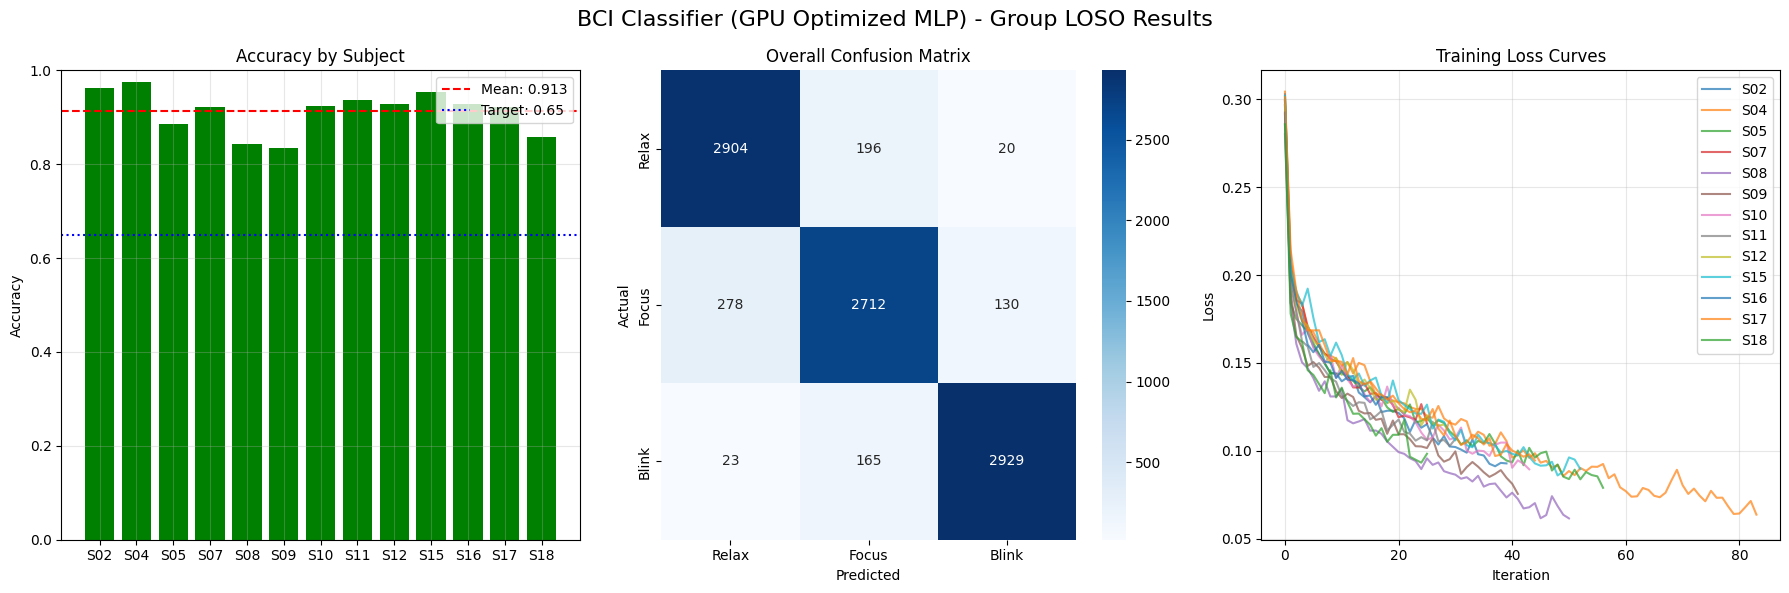


Results saved to 'final_results.png'


In [1]:
"""
Brain-Computer Interface MLP Classifier (PyTorch GPU Version)
For EEG signal relaxation/focus/blink state classification
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
import os
import glob
import warnings

# === 新增 PyTorch 相關套件 ===
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')

# 自動偵測 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🌟 目前使用的運算設備: {device}")

# Parameter Settings
class Config:
    DATASET_PATH = "/kaggle/input/datasets/tzan0602/eeg-dataset-update/bci_dataset_114-2_any"
    
    # MLP model parameters (對齊你給的 Optuna 最佳參數)
    HIDDEN_LAYERS = (224, 160)
    MAX_ITER = 150
    LEARNING_RATE = 0.0034135219881097495
    ALPHA = 0.000016743483425391886
    BATCH_SIZE = 96
    EARLY_STOPPING = True
    VALIDATION_FRACTION = 0.1
    N_ITER_NO_CHANGE = 10
    
    # Signal processing parameters
    SAMPLING_RATE = 512    
    SEGMENT_LENGTH = 6     
    OVERLAP_RATIO = 0.6885411556567583    
    
    # Feature selection parameters
    FEATURE_SELECTION = True
    N_FEATURES_SELECT = 12 
    
    # Other settings
    RANDOM_STATE = 42

def create_segments(data, segment_length_samples, overlap_samples):
    if len(data) < segment_length_samples: return []
    
    segments = []
    start = 0
    step = segment_length_samples - overlap_samples
    
    from scipy.signal import butter, filtfilt
    nyquist = 0.5 * Config.SAMPLING_RATE
    low_cutoff = 1.0 / nyquist  
    high_cutoff = 40.0 / nyquist 
    b, a = butter(4, [low_cutoff, high_cutoff], btype='band')
    
    while start + segment_length_samples <= len(data):
        segment = data[start:start + segment_length_samples]
        segment = filtfilt(b, a, segment)
        segments.append(segment)
        start += step
    return segments

def extract_features(segments):
    features = []
    for seg in segments:
        from scipy.signal import welch
        from scipy.stats import kurtosis
        
        freqs, psd = welch(seg, fs=Config.SAMPLING_RATE, nperseg=Config.SAMPLING_RATE)
        
        delta_idx = np.logical_and(freqs >= 1, freqs < 4)
        theta_idx = np.logical_and(freqs >= 4, freqs < 8)
        alpha_idx = np.logical_and(freqs >= 8, freqs < 13)
        beta_idx  = np.logical_and(freqs >= 13, freqs < 30)
        gamma_idx = np.logical_and(freqs >= 30, freqs <= 40)
        
        delta_power = np.sum(psd[delta_idx])
        theta_power = np.sum(psd[theta_idx])
        alpha_power = np.sum(psd[alpha_idx])
        beta_power  = np.sum(psd[beta_idx])
        gamma_power = np.sum(psd[gamma_idx])
        
        total_power = delta_power + theta_power + alpha_power + beta_power + gamma_power + 1e-6
        rel_alpha = alpha_power / total_power
        rel_beta = beta_power / total_power
        theta_beta_ratio = theta_power / (beta_power + 1e-6)
        
        variance = np.var(seg)
        peak_to_peak = np.ptp(seg)
        kurt = kurtosis(seg) 
        
        current_feature = np.array([
            delta_power, theta_power, alpha_power, beta_power, gamma_power,
            rel_alpha, rel_beta, theta_beta_ratio,
            variance, peak_to_peak, kurt
        ])
        features.append(current_feature)
        
    return np.array(features)

def load_all_subjects():
    all_features, all_labels, all_subjects = [], [], []
    if not os.path.exists(Config.DATASET_PATH):
        print(f"Error: Directory '{Config.DATASET_PATH}' not found")
        return None, None, None
        
    subject_folders = sorted([f.path for f in os.scandir(Config.DATASET_PATH) if f.is_dir()])
    print(f"Found {len(subject_folders)} subjects. Loading data...")
    
    segment_length_samples = int(Config.SEGMENT_LENGTH * Config.SAMPLING_RATE)
    overlap_samples = int(segment_length_samples * Config.OVERLAP_RATIO)

    # 🛡️ 加入完整的壞測資過濾名單
    BAD_SUBJECTS = ['S01', 'S03', 'S06', 'S13', 'S14']

    for subject_folder in subject_folders:
        subject_id = os.path.basename(subject_folder)
        if subject_id in BAD_SUBJECTS:
            print(f"⚠️ 標記 {subject_id} 為壞資料，直接排除。")
            continue
            
        relax_segments, focus_segments, blink_segments = [], [], []
        
        for file in glob.glob(os.path.join(subject_folder, "*_1_*.txt")):
            try: relax_segments.extend(create_segments(np.loadtxt(file), segment_length_samples, overlap_samples))
            except: pass
        for file in glob.glob(os.path.join(subject_folder, "*_2_*.txt")):
            try: focus_segments.extend(create_segments(np.loadtxt(file), segment_length_samples, overlap_samples))
            except: pass
        for file in glob.glob(os.path.join(subject_folder, "*_3_*.txt")):
            try: blink_segments.extend(create_segments(np.loadtxt(file), segment_length_samples, overlap_samples))
            except: pass

        if len(relax_segments) == 0 or len(focus_segments) == 0 or len(blink_segments) == 0:
            continue

        relax_features = extract_features(relax_segments)
        focus_features = extract_features(focus_segments)
        blink_features = extract_features(blink_segments)
        
        relax_labels = np.zeros(len(relax_features))
        focus_labels = np.ones(len(focus_features))
        blink_labels = np.full(len(blink_features), 2)
        
        subject_features = np.vstack([relax_features, focus_features, blink_features])
        
        # 💡 加入受試者獨立標準化 (拉平天生頭皮阻抗差異)
        subject_scaler = StandardScaler()
        subject_features = subject_scaler.fit_transform(subject_features)
        
        subject_labels = np.hstack([relax_labels, focus_labels, blink_labels])
        subject_ids = [subject_id] * len(subject_labels)
        
        all_features.append(subject_features)
        all_labels.append(subject_labels)
        all_subjects.extend(subject_ids)
        
        print(f" - {subject_id}: Successfully loaded {len(relax_segments)} Relax, {len(focus_segments)} Focus, {len(blink_segments)} Blink segments")
    
    if not all_features: return None, None, None
    return np.vstack(all_features), np.hstack(all_labels), all_subjects


# ==========================================
# === PyTorch 版本的 MLP 網路結構 ===
# ==========================================
class PyTorchMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes=3):
        super(PyTorchMLP, self).__init__()
        layers = []
        last_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(last_size, h))
            layers.append(nn.ReLU())
            last_size = h
        layers.append(nn.Linear(last_size, num_classes))
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.model(x)

# ==========================================
# === 取代原本 sklearn 的包裝器 ===
# ==========================================
class EnhancedBCIClassifier:
    def __init__(self):
        self.scaler = StandardScaler()
        self.feature_selector = SelectKBest(f_classif, k=Config.N_FEATURES_SELECT) if Config.FEATURE_SELECTION else None
        self.loss_curve_ = []
        
    def fit(self, X, y):
        # 1. 特徵縮放與選擇
        X_scaled = self.scaler.fit_transform(X)
        if self.feature_selector is not None:
            self.feature_selector.k = min(Config.N_FEATURES_SELECT, X_scaled.shape[1])
            X_selected = self.feature_selector.fit_transform(X_scaled, y)
        else:
            X_selected = X_scaled
            
        input_dim = X_selected.shape[1]
        
        # 2. 建立 PyTorch 模型並送入 GPU
        self.model = PyTorchMLP(input_dim, Config.HIDDEN_LAYERS).to(device)
        criterion = nn.CrossEntropyLoss()
        # 這裡的 weight_decay 對應原本 sklearn 的 ALPHA
        optimizer = optim.Adam(self.model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.ALPHA)
        
        # 3. Early Stopping 切分驗證集
        X_tr, X_val, y_tr, y_val = train_test_split(X_selected, y, test_size=Config.VALIDATION_FRACTION, random_state=Config.RANDOM_STATE)
        
        # 轉換為 Tensor 並放進 GPU
        X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
        y_tr_t = torch.tensor(y_tr, dtype=torch.long).to(device)
        X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
        y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
        
        dataset = TensorDataset(X_tr_t, y_tr_t)
        dataloader = DataLoader(dataset, batch_size=Config.BATCH_SIZE, shuffle=True)
        
        best_val_loss = float('inf')
        epochs_no_improve = 0
        
        # 4. 訓練迴圈
        for epoch in range(Config.MAX_ITER):
            self.model.train()
            epoch_loss = 0
            for batch_X, batch_y in dataloader:
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            
            self.loss_curve_.append(epoch_loss / len(dataloader))
            
            # Early Stopping 邏輯
            if Config.EARLY_STOPPING:
                self.model.eval()
                with torch.no_grad():
                    val_outputs = self.model(X_val_t)
                    val_loss = criterion(val_outputs, y_val_t).item()
                    
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    
                if epochs_no_improve >= Config.N_ITER_NO_CHANGE:
                    # print(f"  [Early stopping triggered at epoch {epoch}]")
                    break
                    
        return self
    
    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        if self.feature_selector is not None:
            X_selected = self.feature_selector.transform(X_scaled)
        else:
            X_selected = X_scaled
            
        self.model.eval()
        X_t = torch.tensor(X_selected, dtype=torch.float32).to(device)
        
        with torch.no_grad():
            outputs = self.model(X_t)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            
        # 套用你的信心權重 (提升 Focus 判定率)
        weights = np.array([0.9, 1.15, 1.0])
        adjusted_probs = probs * weights
        return np.argmax(adjusted_probs, axis=1)
                
    def get_loss_curve(self):
        return self.loss_curve_

# ==========================================
# === 以下 LOSO 與繪圖邏輯皆無需更改 ===
# ==========================================
def leave_one_subject_out_validation():
    print("\nStarting Leave-One-Subject-Out (LOSO) Cross-Validation (GPU Accelerated)...")
    
    X, y, subjects = load_all_subjects()
    if X is None: return None
    
    unique_subjects = sorted(list(set(subjects)))
    results = {'accuracies': [], 'confusion_matrices': [], 'loss_curves': [], 'subject_names': []}
    
    print("\n" + "="*40)
    for test_subject in unique_subjects:
        train_mask = [s != test_subject for s in subjects]
        test_mask = [s == test_subject for s in subjects]
        
        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]
        
        print(f"Training Model (Test Subject: {test_subject}) | Train size: {len(X_train)}, Test size: {len(X_test)}")
        
        classifier = EnhancedBCIClassifier()
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_test)
        
        accuracy = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
        
        results['accuracies'].append(accuracy)
        results['confusion_matrices'].append(cm)
        results['loss_curves'].append(classifier.get_loss_curve())
        results['subject_names'].append(test_subject)
        
        print(f" -> Accuracy: {accuracy:.3f}")
    
    return results

def plot_results(results):
    if results is None: return
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('BCI Classifier (GPU Optimized MLP) - Group LOSO Results', fontsize=16)
    
    subject_names = results['subject_names']
    axes[0].bar(subject_names, results['accuracies'], 
                color=['green' if acc >= 0.7 else 'orange' if acc >= 0.65 else 'red' for acc in results['accuracies']])
    axes[0].set_title('Accuracy by Subject')
    axes[0].set_ylabel('Accuracy')
    axes[0].axhline(y=np.mean(results['accuracies']), color='r', linestyle='--', label=f'Mean: {np.mean(results["accuracies"]):.3f}')
    axes[0].axhline(y=0.65, color='blue', linestyle=':', label='Target: 0.65')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 1)
    
    total_cm = np.sum(results['confusion_matrices'], axis=0)
    sns.heatmap(total_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Relax', 'Focus', 'Blink'], yticklabels=['Relax', 'Focus', 'Blink'], ax=axes[1])
    axes[1].set_title('Overall Confusion Matrix')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    
    valid_loss_curves = [lc for lc in results['loss_curves'] if len(lc) > 0]
    if valid_loss_curves:
        for i, loss_curve in enumerate(valid_loss_curves):
            axes[2].plot(loss_curve, alpha=0.7, label=subject_names[i])
        axes[2].set_title('Training Loss Curves')
        axes[2].set_xlabel('Iteration')
        axes[2].set_ylabel('Loss')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('final_results.png', dpi=300, bbox_inches='tight')
    plt.show()

def main():
    print("BCI EEG Classification - GPU Group Evaluation")
    print("=" * 60)
    
    results = leave_one_subject_out_validation()
    if results is None:
        print("Validation failed! Please check your directory structure.")
        return
    
    mean_accuracy = np.mean(results['accuracies'])
    std_accuracy = np.std(results['accuracies'])
    
    print("\n" + "="*40)
    print(f"Overall Mean Accuracy: {mean_accuracy:.3f} ± {std_accuracy:.3f}")
    
    total_cm = np.sum(results['confusion_matrices'], axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        relax_accuracy = total_cm[0, 0] / np.sum(total_cm[0, :]) if np.sum(total_cm[0, :]) > 0 else 0
        concentration_accuracy = total_cm[1, 1] / np.sum(total_cm[1, :]) if np.sum(total_cm[1, :]) > 0 else 0
        blink_accuracy = total_cm[2, 2] / np.sum(total_cm[2, :]) if np.sum(total_cm[2, :]) > 0 else 0
        relax_precision = total_cm[0, 0] / np.sum(total_cm[:, 0]) if np.sum(total_cm[:, 0]) > 0 else 0
        concentration_precision = total_cm[1, 1] / np.sum(total_cm[:, 1]) if np.sum(total_cm[:, 1]) > 0 else 0
        blink_precision = total_cm[2, 2] / np.sum(total_cm[:, 2]) if np.sum(total_cm[:, 2]) > 0 else 0

    print(f"\n[Relax Class]")
    print(f"  - Accuracy (Recall): {relax_accuracy:.3f} ({total_cm[0, 0]}/{np.sum(total_cm[0, :])})")
    print(f"  - Precision: {relax_precision:.3f} ({total_cm[0, 0]}/{np.sum(total_cm[:, 0])})")
    
    print(f"\n[Focus Class]")
    print(f"  - Accuracy (Recall): {concentration_accuracy:.3f} ({total_cm[1, 1]}/{np.sum(total_cm[1, :])})")
    print(f"  - Precision: {concentration_precision:.3f} ({total_cm[1, 1]}/{np.sum(total_cm[:, 1])})")
    
    print(f"\n[Blink Class]")
    print(f"  - Accuracy (Recall): {blink_accuracy:.3f} ({total_cm[2, 2]}/{np.sum(total_cm[2, :])})")
    print(f"  - Precision: {blink_precision:.3f} ({total_cm[2, 2]}/{np.sum(total_cm[:, 2])})")
    
    plot_results(results)
    print(f"\nResults saved to 'final_results.png'")

if __name__ == "__main__":
    main()

In [1]:
!pip install optuna

In [12]:
import optuna
import random
import numpy as np
import glob
import os
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from scipy.signal import butter, filtfilt, welch
from scipy.stats import kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from collections import defaultdict

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 🎯 抓鬼名單與路徑設定
# ==========================================
BAD_SUBJECTS = ['S13', 'S14']
DATASET_PATH = "/kaggle/input/datasets/tzan0602/eeg-dataset-update/bci_dataset_114-2_any"

# ==========================================
# 1. 載入原始資料到記憶體 (RAM Cache 加速)
# ==========================================
print(f"🌟 目前使用的運算設備: {device}")
print("📂 正在尋找 Kaggle 上的腦波檔案...")
all_txt_files = glob.glob(os.path.join(DATASET_PATH, "**/*.txt"), recursive=True)

if not all_txt_files:
    raise ValueError("❌ 找不到任何 .txt 檔案！請確認 Dataset 路徑是否正確。")

subject_files = defaultdict(list)
for file_path in all_txt_files:
    filename = os.path.basename(file_path)
    parts = filename.replace('.txt', '').split('_')
    if len(parts) >= 3:
        subject_id = parts[0]
        if subject_id not in BAD_SUBJECTS:
            subject_files[subject_id].append((file_path, parts[1]))

print(f"🧹 已踢除 {len(BAD_SUBJECTS)} 位壞受試者: {BAD_SUBJECTS}")
print(f"✅ 找到 {len(subject_files)} 位乾淨受試者。開始載入記憶體...")

RAW_CACHE = defaultdict(lambda: {'1': [], '2': [], '3': []})
for subject_id, files_info in subject_files.items():
    for file_path, task_type in files_info:
        try:
            data = np.loadtxt(file_path)
            if task_type in ['1', '2', '3']:
                RAW_CACHE[subject_id][task_type].append(data)
        except:
            pass
print("🚀 乾淨的原始資料載入完成！")
print("=" * 60)

# ==========================================
# 2. 定義模型與最新特徵萃取函數 (含 Hjorth)
# ==========================================
class PyTorchMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes=3):
        super(PyTorchMLP, self).__init__()
        layers = []
        last_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(last_size, h))
            layers.append(nn.ReLU())
            last_size = h
        layers.append(nn.Linear(last_size, num_classes))
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.model(x)

def process_data_for_trial(overlap_ratio):
    SAMPLING_RATE = 512
    SEGMENT_LENGTH = 6
    segment_length_samples = int(SEGMENT_LENGTH * SAMPLING_RATE)
    overlap_samples = int(segment_length_samples * overlap_ratio)
    
    nyquist = 0.5 * SAMPLING_RATE
    b, a = butter(4, [1.0/nyquist, 40.0/nyquist], btype='band')
    
    all_features, all_labels, all_subjects = [], [], []
    
    for subject_id, tasks_data in RAW_CACHE.items():
        sub_relax, sub_focus, sub_blink = [], [], []
        
        for task_id, raw_arrays in tasks_data.items():
            for raw_data in raw_arrays:
                if len(raw_data) < segment_length_samples: continue
                start = 0
                step = segment_length_samples - overlap_samples
                while start + segment_length_samples <= len(raw_data):
                    segment = raw_data[start:start + segment_length_samples]
                    segment = filtfilt(b, a, segment) 
                    
                    # 萃取 14 個特徵 (包含 Hjorth)
                    freqs, psd = welch(segment, fs=SAMPLING_RATE, nperseg=SAMPLING_RATE)
                    delta_power = np.sum(psd[(freqs >= 1) & (freqs < 4)])
                    theta_power = np.sum(psd[(freqs >= 4) & (freqs < 8)])
                    alpha_power = np.sum(psd[(freqs >= 8) & (freqs < 13)])
                    beta_power  = np.sum(psd[(freqs >= 13) & (freqs < 30)])
                    gamma_power = np.sum(psd[(freqs >= 30) & (freqs <= 40)])
                    total_power = delta_power + theta_power + alpha_power + beta_power + gamma_power + 1e-6
                    rel_alpha = alpha_power / total_power
                    rel_beta = beta_power / total_power
                    theta_beta_ratio = theta_power / (beta_power + 1e-6)
                    
                    variance = np.var(segment)
                    peak_to_peak = np.ptp(segment)
                    kurt = kurtosis(segment) 
                    
                    activity = variance
                    diff1 = np.diff(segment)
                    mobility = np.sqrt(np.var(diff1) / activity) if activity > 0 else 0
                    diff2 = np.diff(diff1)
                    complexity = np.sqrt(np.var(diff2) / np.var(diff1)) / mobility if mobility > 0 and np.var(diff1) > 0 else 0
                    
                    feat_array = np.array([
                        delta_power, theta_power, alpha_power, beta_power, gamma_power,
                        rel_alpha, rel_beta, theta_beta_ratio,
                        variance, peak_to_peak, kurt,
                        activity, mobility, complexity
                    ])
                    
                    if task_id == '1': sub_relax.append(feat_array)
                    elif task_id == '2': sub_focus.append(feat_array)
                    elif task_id == '3': sub_blink.append(feat_array)
                    start += step
                    
        if not sub_relax or not sub_focus or not sub_blink: continue
            
        sub_features = np.vstack([sub_relax, sub_focus, sub_blink])
        sub_labels = np.hstack([np.zeros(len(sub_relax)), np.ones(len(sub_focus)), np.full(len(sub_blink), 2)])
        
        # 受試者獨立標準化 (極為關鍵)
        scaler = StandardScaler()
        sub_features = scaler.fit_transform(sub_features) 
        
        all_features.append(sub_features)
        all_labels.append(sub_labels)
        all_subjects.extend([subject_id] * len(sub_labels))
            
    return np.vstack(all_features), np.hstack(all_labels), all_subjects


# ==========================================
# 3. 定義 Optuna 搜尋邏輯
# ==========================================
# 為了加速，隨機挑選 4 人做調參 (Mini-LOSO)
random.seed(42)
clean_subjects = list(RAW_CACHE.keys())
tune_subjects = random.sample(clean_subjects, min(4, len(clean_subjects)))
print(f"⚡ 將使用以下 {len(tune_subjects)} 人進行 Mini-LOSO 調參：{tune_subjects}")

def objective(trial):
    # --- 最新版 MLP 的超參數搜尋空間 ---
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_sizes = tuple(trial.suggest_int(f'n_units_l{i}', 64, 256, step=32) for i in range(n_layers))
    
    lr = trial.suggest_float('LEARNING_RATE', 1e-4, 1e-2, log=True)
    alpha = trial.suggest_float('ALPHA', 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical('BATCH_SIZE', [32, 64, 96, 128])
    overlap_ratio = trial.suggest_float('OVERLAP_RATIO', 0.2, 0.75)
    
    # 產生當前參數下的 14 維特徵資料
    X_all, y_all, subjects_all = process_data_for_trial(overlap_ratio)
    
    accuracies = []
    
    for test_subject in tune_subjects:
        train_mask = [s != test_subject for s in subjects_all]
        test_mask = [s == test_subject for s in subjects_all]
        
        X_train, X_test = X_all[train_mask], X_all[test_mask]
        y_train, y_test = y_all[train_mask], y_all[test_mask]
        
        # 轉換為 TensorDataset
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
        dataset = TensorDataset(X_train_t, y_train_t)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        input_dim = X_train.shape[1] # 應該要是 14
        
        # 初始化模型與優化器
        model = PyTorchMLP(input_dim, hidden_sizes).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=alpha)
        
        # 訓練模型 (固定跑 100 個 Epoch 以節省調參時間)
        model.train()
        for epoch in range(100):
            for batch_X, batch_y in dataloader:
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                
        # 驗證模型
        model.eval()
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
        with torch.no_grad():
            outputs = model(X_test_t)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            
            # 使用最新的微調版信心權重
            weights = np.array([1.0, 1.0, 1.0])
            y_pred = np.argmax(probs * weights, axis=1)
            
            acc = accuracy_score(y_test, y_pred)
            accuracies.append(acc)
            
    return np.mean(accuracies)

# ==========================================
# 4. 啟動最佳化
# ==========================================
print("\n⏳ 開始執行 GPU PyTorch MLP 自動調參 (預計約需 15~30 分鐘)...")
study = optuna.create_study(direction='maximize', study_name="PyTorch_MLP_V2_Optimization")

# 跑 30 次測試
study.optimize(objective, n_trials=30) 

print("\n" + "="*50)
print("🎉 調參完成！")
print(f"🌟 Mini-LOSO 最佳平均準確率: {study.best_value:.4f}")
print("👑 請將以下最佳參數填回你主程式的 Config 中:")

best_hidden_layers = tuple(study.best_params[f'n_units_l{i}'] for i in range(study.best_params['n_layers']))
print(f"  - HIDDEN_LAYERS: {best_hidden_layers}")
print(f"  - LEARNING_RATE: {study.best_params['LEARNING_RATE']}")
print(f"  - ALPHA: {study.best_params['ALPHA']}")
print(f"  - BATCH_SIZE: {study.best_params['BATCH_SIZE']}")
print(f"  - OVERLAP_RATIO: {study.best_params['OVERLAP_RATIO']}")
print(f"  (注意: N_FEATURES_SELECT 已不再需要，請確保主程式設為 FEATURE_SELECTION = False)")

try:
    fig1 = optuna.visualization.plot_optimization_history(study)
    fig1.show()
    fig2 = optuna.visualization.plot_param_importances(study)
    fig2.show()
except:
    pass

🌟 目前使用的運算設備: cuda
📂 正在尋找 Kaggle 上的腦波檔案...
🧹 已踢除 2 位壞受試者: ['S13', 'S14']
✅ 找到 16 位乾淨受試者。開始載入記憶體...


[I 2026-05-18 12:16:04,330] A new study created in memory with name: PyTorch_MLP_V2_Optimization


🚀 乾淨的原始資料載入完成！
⚡ 將使用以下 4 人進行 Mini-LOSO 調參：['S06', 'S18', 'S17', 'S10']

⏳ 開始執行 GPU PyTorch MLP 自動調參 (預計約需 15~30 分鐘)...


[I 2026-05-18 12:17:51,586] Trial 0 finished with value: 0.8534722222222222 and parameters: {'n_layers': 1, 'n_units_l0': 128, 'LEARNING_RATE': 0.006202713618401669, 'ALPHA': 2.7807009217259256e-05, 'BATCH_SIZE': 32, 'OVERLAP_RATIO': 0.388835900047239}. Best is trial 0 with value: 0.8534722222222222.
[I 2026-05-18 12:20:04,934] Trial 1 finished with value: 0.8513888888888889 and parameters: {'n_layers': 3, 'n_units_l0': 160, 'n_units_l1': 224, 'n_units_l2': 256, 'LEARNING_RATE': 0.00016622684114403545, 'ALPHA': 4.0574301673167697e-05, 'BATCH_SIZE': 32, 'OVERLAP_RATIO': 0.3664121609085476}. Best is trial 0 with value: 0.8534722222222222.
[W 2026-05-18 12:20:07,821] Trial 2 failed with parameters: {'n_layers': 3, 'n_units_l0': 128, 'n_units_l1': 192, 'n_units_l2': 192, 'LEARNING_RATE': 0.0015776411085903475, 'ALPHA': 1.7246547322951606e-05, 'BATCH_SIZE': 32, 'OVERLAP_RATIO': 0.661671871505689} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File 

KeyboardInterrupt: 

# 測資檢查

🔍 正在尋找 S02 (對照組) 與 S10 (抓鬼目標) 的原始資料...


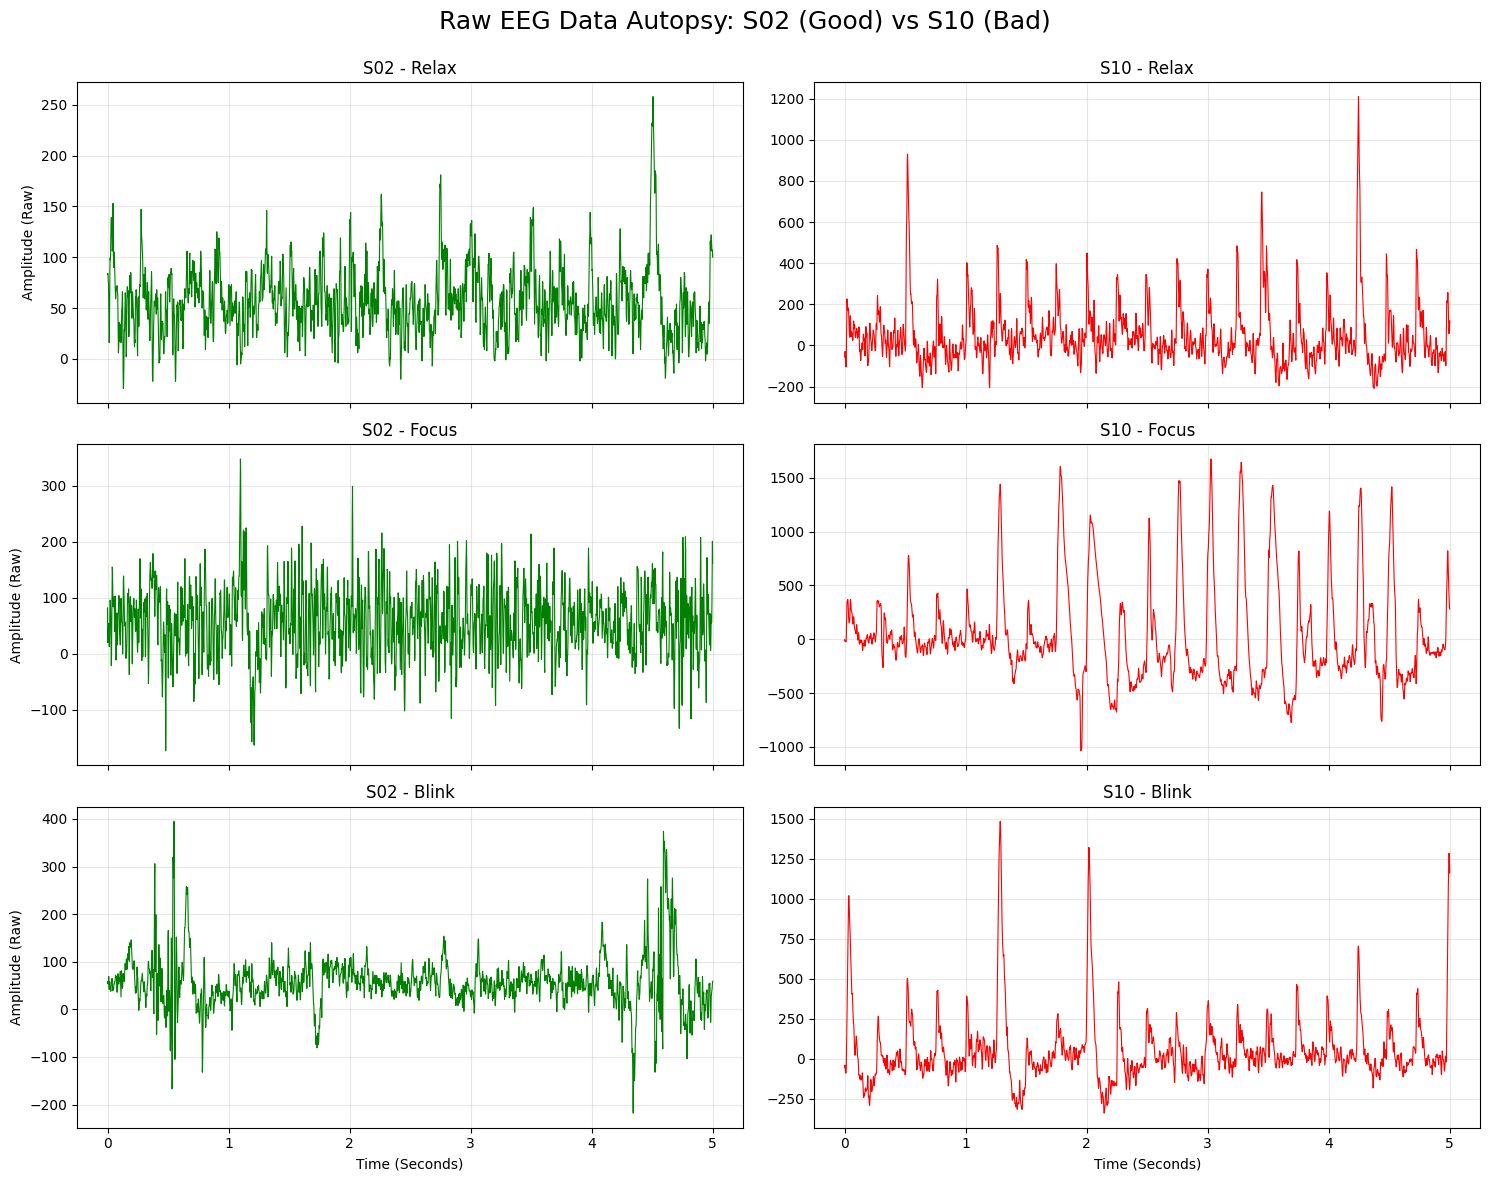

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ==========================================
# 抓鬼設定區
# ==========================================
# 請將這裡改成你在圖表上看到的、或者是實際的檔名前綴
# 如果你的檔案是 b12901056_1_1.txt，請填 "b12901056"
GOOD_SUBJECT = "S02" 
BAD_SUBJECT = "S10"  

# 預設看每個人第 1 回合的資料 (取前 5 秒來放大觀察)
ROUND_NUM = "1"
SECONDS_TO_SHOW = 5
FS = 512 # 取樣率
SAMPLES = SECONDS_TO_SHOW * FS

def find_and_load_file(subject, task_id, round_num):
    """在 Kaggle 全域尋找特定的腦波檔案"""
    search_pattern = f"/kaggle/input/**/*{subject}_{task_id}_{round_num}.txt"
    files = glob.glob(search_pattern, recursive=True)
    
    if not files:
        # 容錯機制：有些組別命名可能是 S02_1_01.txt
        search_pattern_alt = f"/kaggle/input/**/*{subject}_{task_id}_0{round_num}.txt"
        files = glob.glob(search_pattern_alt, recursive=True)
        
    if files:
        try:
            return np.loadtxt(files[0])[:SAMPLES]
        except:
            return None
    return None

# ==========================================
# 讀取資料
# ==========================================
tasks = {'1': 'Relax', '2': 'Focus', '3': 'Blink'}
good_data = {}
bad_data = {}

print(f"🔍 正在尋找 {GOOD_SUBJECT} (對照組) 與 {BAD_SUBJECT} (抓鬼目標) 的原始資料...")

for task_id, task_name in tasks.items():
    good_data[task_name] = find_and_load_file(GOOD_SUBJECT, task_id, ROUND_NUM)
    bad_data[task_name] = find_and_load_file(BAD_SUBJECT, task_id, ROUND_NUM)

# ==========================================
# 畫出驗屍對照圖
# ==========================================
fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
fig.suptitle(f'Raw EEG Data Autopsy: {GOOD_SUBJECT} (Good) vs {BAD_SUBJECT} (Bad)', fontsize=18)

time_axis = np.linspace(0, SECONDS_TO_SHOW, SAMPLES)

for i, task_name in enumerate(tasks.values()):
    # 畫 Good Subject
    ax_good = axes[i, 0]
    if good_data[task_name] is not None:
        ax_good.plot(time_axis, good_data[task_name], color='green', linewidth=0.8)
        ax_good.set_title(f'{GOOD_SUBJECT} - {task_name}')
        ax_good.grid(True, alpha=0.3)
    else:
        ax_good.text(0.5, 0.5, 'File Not Found', ha='center', va='center')
        
    # 畫 Bad Subject
    ax_bad = axes[i, 1]
    if bad_data[task_name] is not None:
        ax_bad.plot(time_axis, bad_data[task_name], color='red', linewidth=0.8)
        ax_bad.set_title(f'{BAD_SUBJECT} - {task_name}')
        ax_bad.grid(True, alpha=0.3)
    else:
        ax_bad.text(0.5, 0.5, 'File Not Found', ha='center', va='center')

# 設定軸標籤
for ax in axes[-1, :]:
    ax.set_xlabel('Time (Seconds)')
for ax in axes[:, 0]:
    ax.set_ylabel('Amplitude (Raw)')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


🎨 正在繪製 Good 組 (13 人) 的腦波驗屍圖...
✅ 圖片已儲存為：good_subjects_autopsy.png


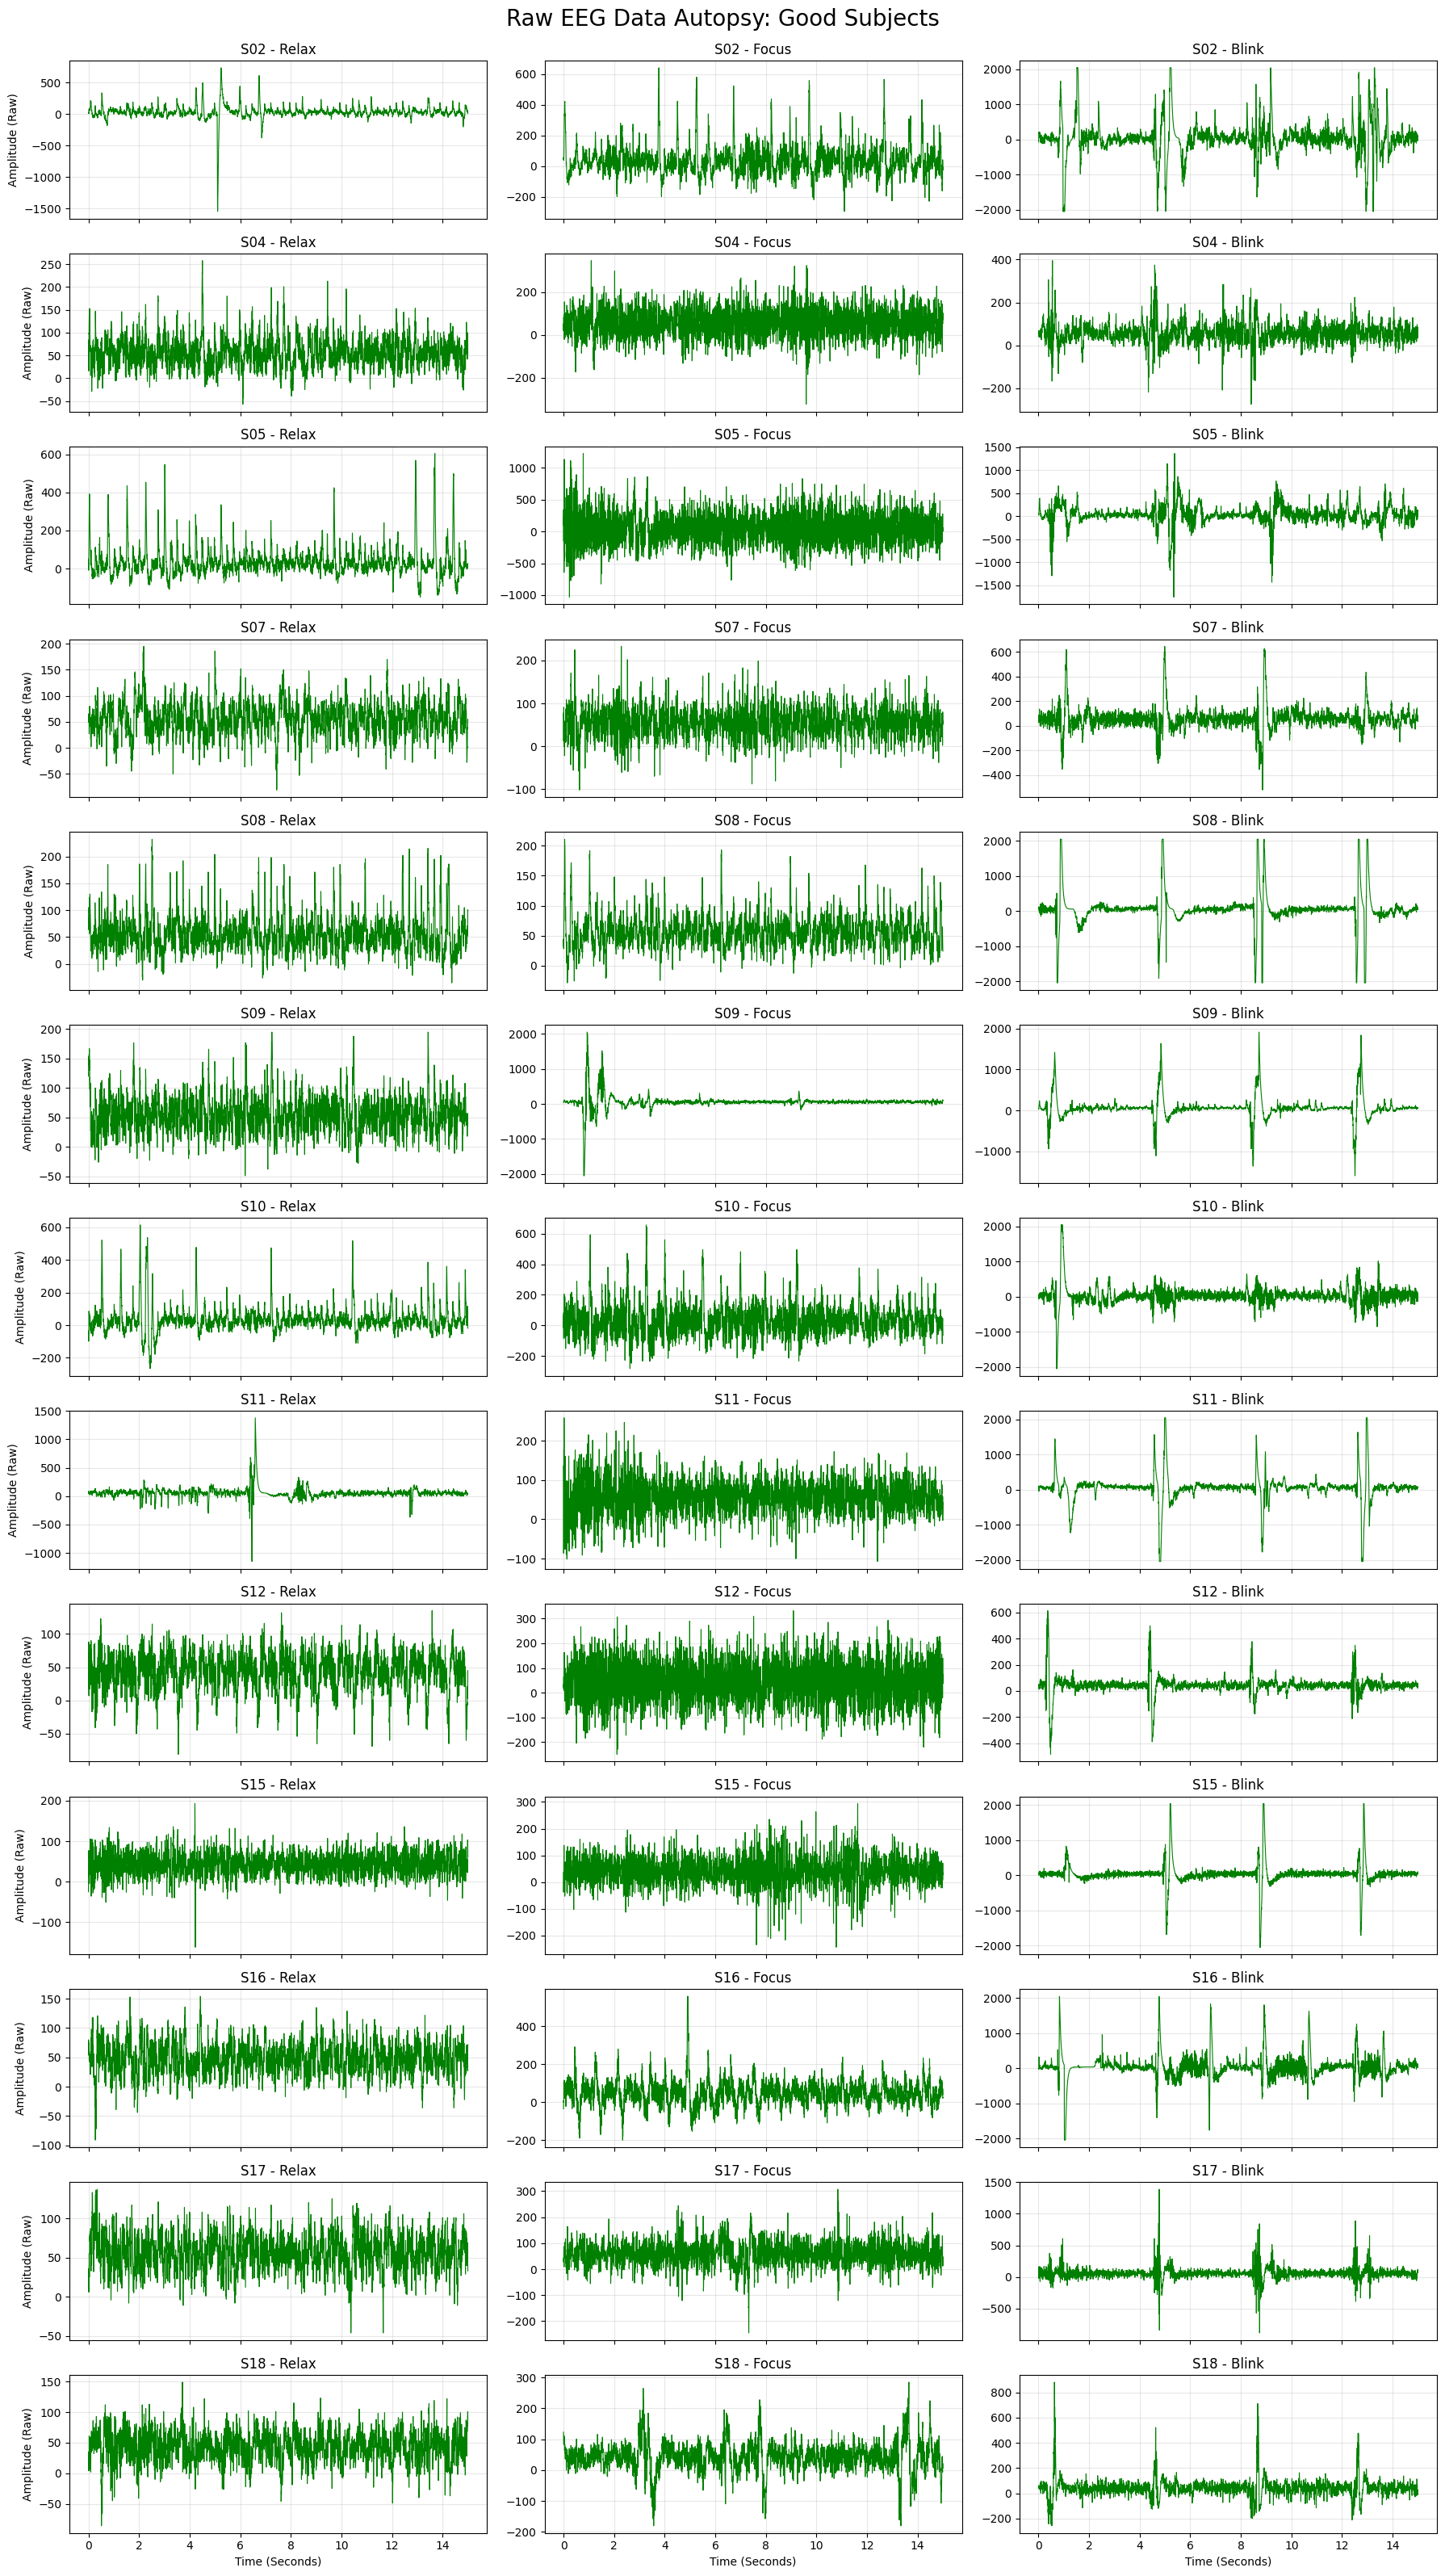


🎨 正在繪製 Bad (Outliers) 組 (5 人) 的腦波驗屍圖...
✅ 圖片已儲存為：bad_subjects_autopsy.png


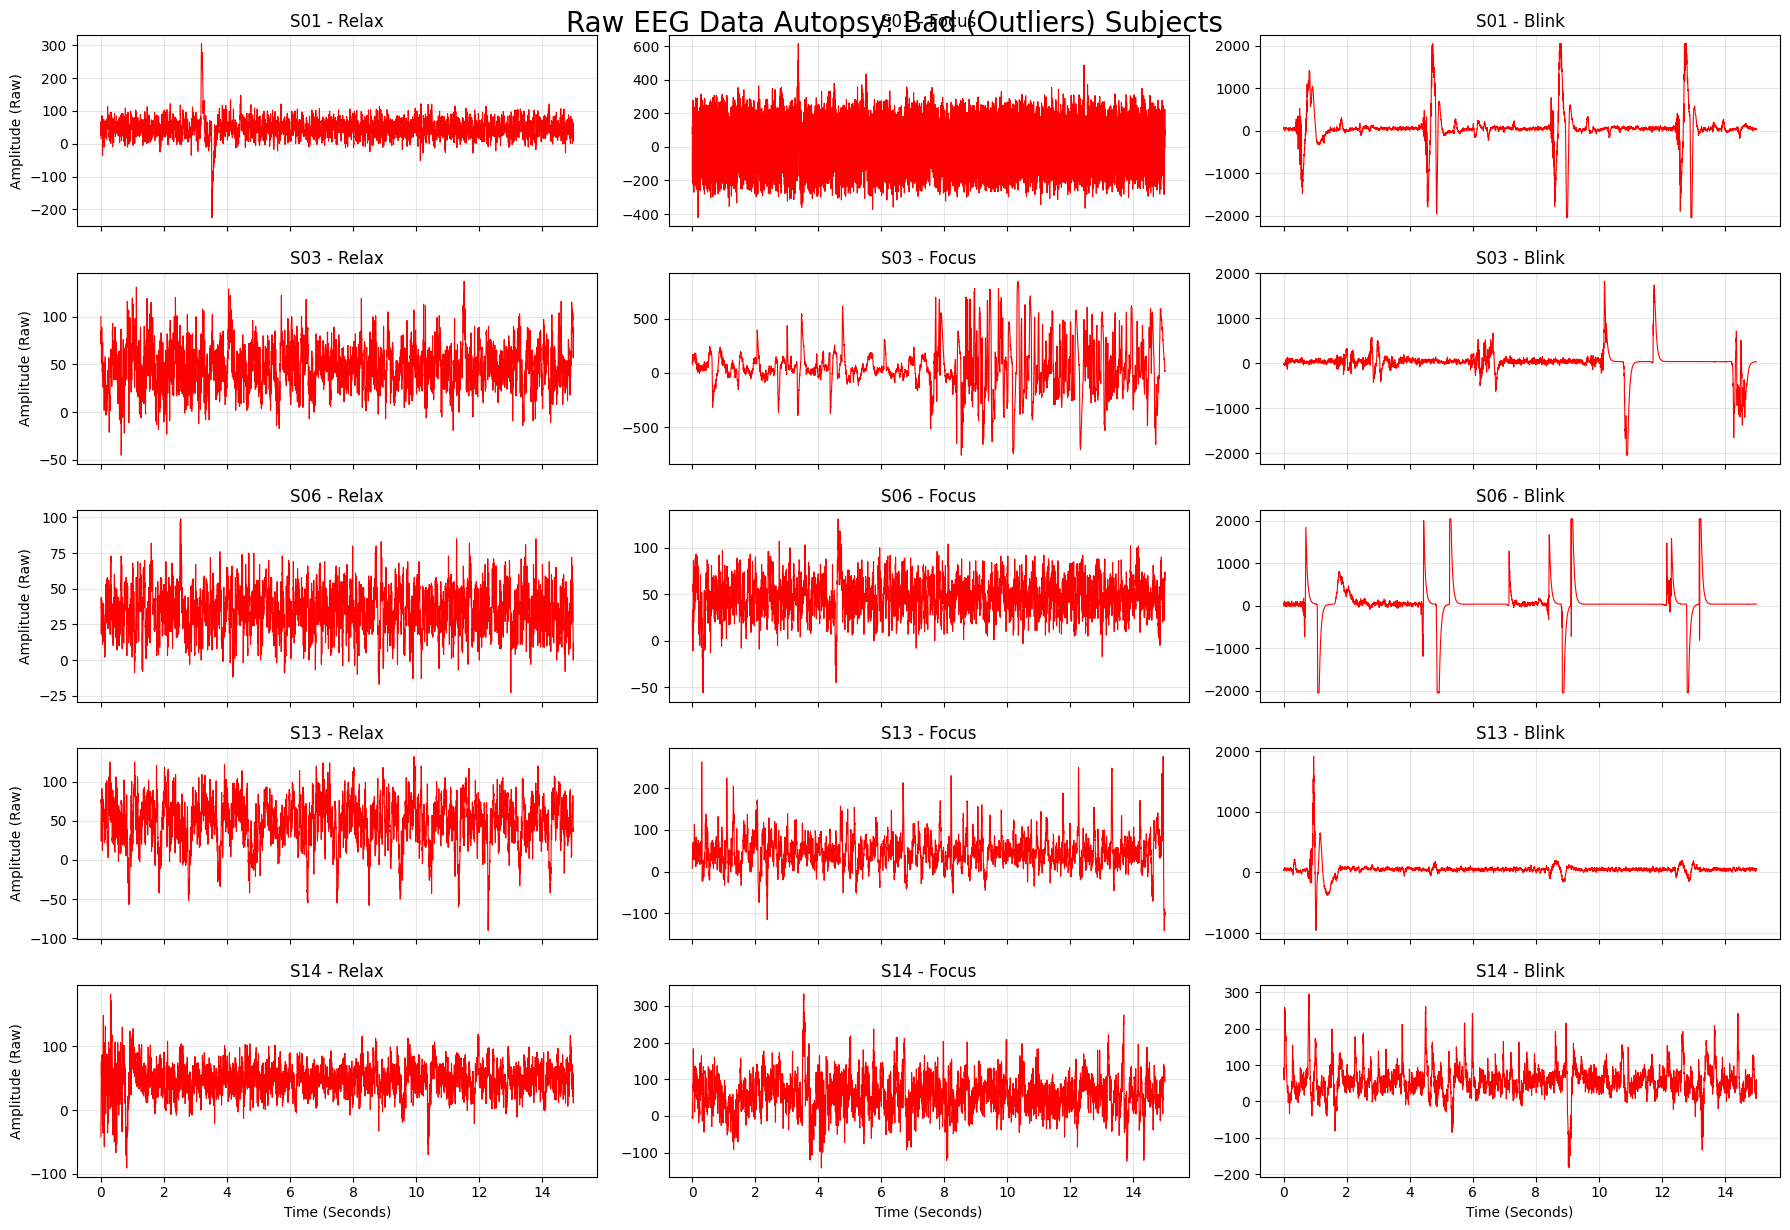

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ==========================================
# 抓鬼設定區：定義好人與壞人名單
# ==========================================
# 5 個表現極差的受試者
BAD_SUBJECTS = ['S01', 'S03', 'S06', 'S13', 'S14']

# 自動產生所有 18 人的名單 (S01 ~ S18)
ALL_SUBJECTS = [f'S{i:02d}' for i in range(1, 19)]

# 扣除壞人，剩下就是 13 個好人
GOOD_SUBJECTS = [s for s in ALL_SUBJECTS if s not in BAD_SUBJECTS]

# 預設看每個人第 1 回合的資料 (取前 5 秒來放大觀察)
ROUND_NUM = "1"
SECONDS_TO_SHOW = 15
FS = 512 # 取樣率
SAMPLES = SECONDS_TO_SHOW * FS
tasks = {'1': 'Relax', '2': 'Focus', '3': 'Blink'}

def find_and_load_file(subject, task_id, round_num):
    """在 Kaggle 全域尋找特定的腦波檔案"""
    search_pattern = f"/kaggle/input/**/*{subject}_{task_id}_{round_num}.txt"
    files = glob.glob(search_pattern, recursive=True)
    
    if not files:
        # 容錯機制
        search_pattern_alt = f"/kaggle/input/**/*{subject}_{task_id}_0{round_num}.txt"
        files = glob.glob(search_pattern_alt, recursive=True)
        
    if files:
        try:
            return np.loadtxt(files[0])[:SAMPLES]
        except:
            return None
    return None

def plot_subject_group(subjects_list, group_name, line_color, filename):
    """通用的繪圖函數，用來畫出一整組人的波形"""
    n_subjects = len(subjects_list)
    print(f"\n🎨 正在繪製 {group_name} 組 ({n_subjects} 人) 的腦波驗屍圖...")
    
    # 動態調整圖片高度，人越多圖越長 (每人分配約 2.5 吋的高度)
    fig, axes = plt.subplots(n_subjects, 3, figsize=(18, 2.5 * n_subjects), sharex=True)
    fig.suptitle(f'Raw EEG Data Autopsy: {group_name} Subjects', fontsize=20, y=0.98)
    
    time_axis = np.linspace(0, SECONDS_TO_SHOW, SAMPLES)
    
    for i, subject in enumerate(subjects_list):
        for j, (task_id, task_name) in enumerate(tasks.items()):
            # 讀取資料
            data = find_and_load_file(subject, task_id, ROUND_NUM)
            ax = axes[i, j]
            
            if data is not None:
                ax.plot(time_axis, data, color=line_color, linewidth=0.8)
                ax.set_title(f'{subject} - {task_name}')
                ax.grid(True, alpha=0.3)
            else:
                ax.text(0.5, 0.5, 'File Not Found', ha='center', va='center', color='red')
                
            # 設定 X 軸 (只有最底下一排才顯示秒數標籤)
            if i == n_subjects - 1:
                ax.set_xlabel('Time (Seconds)')
            # 設定 Y 軸 (只有最左邊那一排才顯示 Amplitude 標籤)
            if j == 0:
                ax.set_ylabel('Amplitude (Raw)')

    plt.tight_layout()
    # 稍微往下壓一點，避免標題跟第一排圖表重疊
    plt.subplots_adjust(top=0.96) 
    
    # 存檔
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"✅ 圖片已儲存為：{filename}")
    plt.show()

# ==========================================
# 執行繪圖
# ==========================================
# 1. 畫出 13 個好人的圖 (綠色)
plot_subject_group(GOOD_SUBJECTS, "Good", "green", "good_subjects_autopsy.png")

# 2. 畫出 5 個壞人的圖 (紅色)
plot_subject_group(BAD_SUBJECTS, "Bad (Outliers)", "red", "bad_subjects_autopsy.png")

# EEGNET

🌟 目前使用的運算設備: cuda
BCI EEG Classification - Deep Learning Evaluation

Starting Leave-One-Subject-Out (LOSO) Cross-Validation with Deep Learning...
📂 找到 18 位受試者資料夾。開始讀取資料...
 - S01: 成功載入 120 放鬆, 120 專注, 120 眨眼
 - S02: 成功載入 120 放鬆, 120 專注, 120 眨眼
 - S03: 成功載入 120 放鬆, 120 專注, 120 眨眼
 - S04: 成功載入 120 放鬆, 120 專注, 120 眨眼
 - S05: 成功載入 120 放鬆, 120 專注, 120 眨眼
 - S06: 成功載入 120 放鬆, 120 專注, 120 眨眼
 - S07: 成功載入 120 放鬆, 120 專注, 120 眨眼
 - S08: 成功載入 120 放鬆, 120 專注, 120 眨眼
 - S09: 成功載入 120 放鬆, 120 專注, 120 眨眼
 - S10: 成功載入 120 放鬆, 120 專注, 120 眨眼
 - S11: 成功載入 120 放鬆, 120 專注, 119 眨眼
 - S12: 成功載入 120 放鬆, 120 專注, 120 眨眼
⚠️ 標記 S13 為壞資料，直接排除。
⚠️ 標記 S14 為壞資料，直接排除。
 - S15: 成功載入 120 放鬆, 120 專注, 120 眨眼
 - S16: 成功載入 120 放鬆, 120 專注, 120 眨眼
 - S17: 成功載入 120 放鬆, 120 專注, 120 眨眼
 - S18: 成功載入 120 放鬆, 120 專注, 120 眨眼

Training Model (Test Subject: S01) | Train size: 5399, Test size: 360
 -> Accuracy: 0.697
Training Model (Test Subject: S02) | Train size: 5399, Test size: 360
 -> Accuracy: 0.833
Training Model (Test Subject:

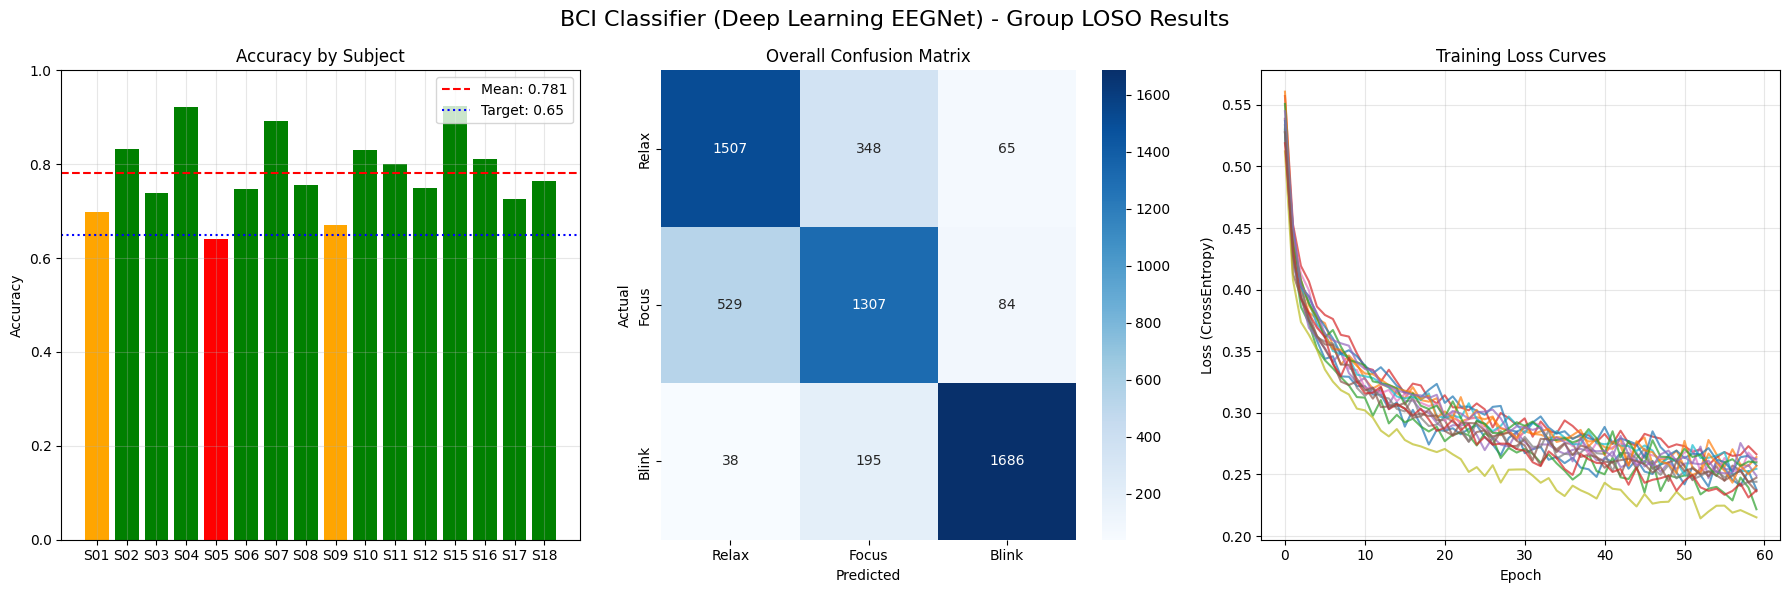


Results saved to 'final_results.png'


In [2]:
"""
Brain-Computer Interface EEGNet Classifier (BrainLink Version)
For EEG signal relaxation/focus/blink state classification
USING DEEP LEARNING (PyTorch GPU Version)
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# 匯入 PyTorch 相關套件
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# 自動偵測 Kaggle GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🌟 目前使用的運算設備: {device}")

# Parameter Settings
class Config:
    # Dataset path settings (符合你的 Kaggle 路徑)
    DATASET_PATH = "/kaggle/input/datasets/tzan0602/eeg-dataset-update/bci_dataset_114-2_any"
    
    # 深度學習 (EEGNet) 參數
    EPOCHS = 60           # 深度學習通常需要多一點 Epochs
    LEARNING_RATE = 0.002
    BATCH_SIZE = 32       # 使用你之前 Optuna 找出的 Batch Size
    WEIGHT_DECAY = 0.02   # L2 正則化 (防止 Overfitting)
    
    # Signal processing parameters
    SAMPLING_RATE = 512    # BrainLink fixed sampling rate
    SEGMENT_LENGTH = 6     # Segment length in seconds
    OVERLAP_RATIO = 0.36379762866224014    # 沿用你最佳化的 Overlap ratio
    
    # Other settings
    RANDOM_STATE = 42

# ==========================================
# === EEGNet 模型定義 (PyTorch) ===
# ==========================================
class EEGNet1D(nn.Module):
    """
    針對單通道 (BrainLink) 調整的 1D-EEGNet
    處理 (Batch, 1, TimeSteps) 的原始訊號
    """
    def __init__(self, classes=3, samples=3072, F1=16, D=2, F2=32):
        super(EEGNet1D, self).__init__()
        
        self.feature_extractor = nn.Sequential(
            # Block 1: Temporal Convolution
            nn.Conv1d(1, F1, kernel_size=64, padding='same', bias=False),
            nn.BatchNorm1d(F1),
            
            # Block 2: Depthwise Convolution
            nn.Conv1d(F1, F1 * D, kernel_size=1, groups=F1, bias=False),
            nn.BatchNorm1d(F1 * D),
            nn.ELU(),
            nn.AvgPool1d(4),
            nn.Dropout(0.3),
            
            # Block 3: Separable Convolution
            nn.Conv1d(F1 * D, F2, kernel_size=16, padding='same', bias=False),
            nn.BatchNorm1d(F2),
            nn.ELU(),
            nn.AvgPool1d(8),
            nn.Dropout(0.3)
        )
        
        # 動態計算全連接層維度
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, samples)
            dummy_output = self.feature_extractor(dummy_input)
            fc_in_features = dummy_output.view(1, -1).shape[1]
            
        self.classifier = nn.Linear(fc_in_features, classes)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1) 
        x = self.classifier(x)
        return x

# ==========================================
# === 資料前處理與讀取 ===
# ==========================================
def create_segments(data, segment_length_samples, overlap_samples):
    """將原始 EEG 訊號切段並進行帶通濾波 (不再計算頻域特徵)"""
    if len(data) < segment_length_samples:
        return []
    
    segments = []
    start = 0
    step = segment_length_samples - overlap_samples
    
    from scipy.signal import butter, filtfilt
    nyquist = 0.5 * Config.SAMPLING_RATE
    low_cutoff = 1.0 / nyquist  
    high_cutoff = 40.0 / nyquist 
    b, a = butter(4, [low_cutoff, high_cutoff], btype='band')
    
    while start + segment_length_samples <= len(data):
        segment = data[start:start + segment_length_samples]
        # 濾波後直接保留波形，交給 EEGNet 自動學特徵
        segment = filtfilt(b, a, segment)
        segments.append(segment)
        start += step
    
    return segments

def load_all_subjects():
    """讀取所有受試者資料，並過濾壞測資"""
    all_segments = []
    all_labels = []
    all_subjects = []
    
    if not os.path.exists(Config.DATASET_PATH):
        print(f"❌ 錯誤: 找不到路徑 '{Config.DATASET_PATH}'")
        return None, None, None
        
    subject_folders = sorted([f.path for f in os.scandir(Config.DATASET_PATH) if f.is_dir()])
    
    print(f"📂 找到 {len(subject_folders)} 位受試者資料夾。開始讀取資料...")
    
    segment_length_samples = int(Config.SEGMENT_LENGTH * Config.SAMPLING_RATE)
    overlap_samples = int(segment_length_samples * Config.OVERLAP_RATIO)

    for subject_folder in subject_folders:
        subject_id = os.path.basename(subject_folder)
        
        # 🛡️ 排除指定的壞測資
        if subject_id in ['S13', 'S14']:
            print(f"⚠️ 標記 {subject_id} 為壞資料，直接排除。")
            continue
            
        relax_segs, focus_segs, blink_segs = [], [], []
        
        for file in glob.glob(os.path.join(subject_folder, "*_1_*.txt")):
            try: relax_segs.extend(create_segments(np.loadtxt(file), segment_length_samples, overlap_samples))
            except: pass

        for file in glob.glob(os.path.join(subject_folder, "*_2_*.txt")):
            try: focus_segs.extend(create_segments(np.loadtxt(file), segment_length_samples, overlap_samples))
            except: pass
        
        for file in glob.glob(os.path.join(subject_folder, "*_3_*.txt")):
            try: blink_segs.extend(create_segments(np.loadtxt(file), segment_length_samples, overlap_samples))
            except: pass

        if not relax_segs or not focus_segs or not blink_segs: 
            continue

        relax_segs = np.array(relax_segs)
        focus_segs = np.array(focus_segs)
        blink_segs = np.array(blink_segs)
        
        relax_labels = np.zeros(len(relax_segs))
        focus_labels = np.ones(len(focus_segs))
        blink_labels = np.full(len(blink_segs), 2)
        
        subject_data = np.vstack([relax_segs, focus_segs, blink_segs])
        subject_labels = np.hstack([relax_labels, focus_labels, blink_labels])
        
        # 💡 核心技巧：針對每個人獨立做 Z-score 標準化，消除頭皮阻抗差異
        scaler = StandardScaler()
        subject_data = scaler.fit_transform(subject_data.T).T 
        
        all_segments.append(subject_data)
        all_labels.append(subject_labels)
        all_subjects.extend([subject_id] * len(subject_labels))
        
        print(f" - {subject_id}: 成功載入 {len(relax_segs)} 放鬆, {len(focus_segs)} 專注, {len(blink_segs)} 眨眼")
    
    if not all_segments: return None, None, None
    return np.vstack(all_segments), np.hstack(all_labels), all_subjects


# ==========================================
# === 結合 sklearn 風格的 PyTorch 訓練器 ===
# ==========================================
class EnhancedBCIClassifier:
    def __init__(self):
        samples = int(Config.SAMPLING_RATE * Config.SEGMENT_LENGTH)
        # 模型送進 GPU
        self.model = EEGNet1D(classes=3, samples=samples).to(device)
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.AdamW(self.model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)
        self.loss_history = []
        
    def fit(self, X, y):
        # 轉換為 Tensor 並送進 GPU (形狀: Batch, 1 Channel, TimeSteps)
        X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1).to(device)
        y_tensor = torch.tensor(y, dtype=torch.long).to(device)
        
        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=Config.BATCH_SIZE, shuffle=True)
        
        self.model.train()
        for epoch in range(Config.EPOCHS):
            epoch_loss = 0.0
            for batch_X, batch_y in dataloader:
                self.optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = self.criterion(outputs, batch_y)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()
            
            self.loss_history.append(epoch_loss / len(dataloader))
        return self
    
    def predict(self, X):
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1).to(device)
        
        with torch.no_grad():
            outputs = self.model(X_tensor)
            # 使用 Softmax 取得機率，並搬回 CPU 轉為 numpy array
            probs = F.softmax(outputs, dim=1).cpu().numpy()
            
            # --- 信心權重後處理 (保留你原本的設定) ---
            weights = np.array([1.0, 1.0, 1.0])
            adjusted_probs = probs * weights
            
            return np.argmax(adjusted_probs, axis=1)
                
    def get_loss_curve(self):
        return self.loss_history


def leave_one_subject_out_validation():
    print("\nStarting Leave-One-Subject-Out (LOSO) Cross-Validation with Deep Learning...")
    
    X, y, subjects = load_all_subjects()
    if X is None: return None
    
    unique_subjects = sorted(list(set(subjects)))
    results = {'accuracies': [], 'confusion_matrices': [], 'loss_curves': [], 'subject_names': []}
    
    print("\n" + "="*40)
    for test_subject in unique_subjects:
        train_mask = [s != test_subject for s in subjects]
        test_mask = [s == test_subject for s in subjects]
        
        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]
        
        print(f"Training Model (Test Subject: {test_subject}) | Train size: {len(X_train)}, Test size: {len(X_test)}")
        
        classifier = EnhancedBCIClassifier()
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_test)
        
        accuracy = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
        
        results['accuracies'].append(accuracy)
        results['confusion_matrices'].append(cm)
        results['loss_curves'].append(classifier.get_loss_curve())
        results['subject_names'].append(test_subject)
        
        print(f" -> Accuracy: {accuracy:.3f}")
    
    return results


def plot_results(results):
    if results is None: return
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('BCI Classifier (Deep Learning EEGNet) - Group LOSO Results', fontsize=16)
    
    # 1. Accuracy distribution
    subject_names = results['subject_names']
    axes[0].bar(subject_names, results['accuracies'], 
                color=['green' if acc >= 0.7 else 'orange' if acc >= 0.65 else 'red' for acc in results['accuracies']])
    axes[0].set_title('Accuracy by Subject')
    axes[0].set_ylabel('Accuracy')
    axes[0].axhline(y=np.mean(results['accuracies']), color='r', linestyle='--', label=f'Mean: {np.mean(results["accuracies"]):.3f}')
    axes[0].axhline(y=0.65, color='blue', linestyle=':', label='Target: 0.65')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 1)
    
    # 2. Overall confusion matrix
    total_cm = np.sum(results['confusion_matrices'], axis=0)
    sns.heatmap(total_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Relax', 'Focus', 'Blink'], yticklabels=['Relax', 'Focus', 'Blink'], ax=axes[1])
    axes[1].set_title('Overall Confusion Matrix')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    
    # 3. Training loss curves
    valid_loss_curves = [lc for lc in results['loss_curves'] if len(lc) > 0]
    if valid_loss_curves:
        for i, loss_curve in enumerate(valid_loss_curves):
            axes[2].plot(loss_curve, alpha=0.7, label=subject_names[i])
        axes[2].set_title('Training Loss Curves')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Loss (CrossEntropy)')
        if len(subject_names) <= 10:
            axes[2].legend()
        axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('final_results.png', dpi=300, bbox_inches='tight')
    plt.show()

def main():
    print("BCI EEG Classification - Deep Learning Evaluation")
    print("=" * 60)
    
    results = leave_one_subject_out_validation()
    if results is None:
        print("Validation failed! Please check your directory structure.")
        return
    
    mean_accuracy = np.mean(results['accuracies'])
    std_accuracy = np.std(results['accuracies'])
    
    print("\n" + "="*40)
    print(f"Overall Mean Accuracy: {mean_accuracy:.3f} ± {std_accuracy:.3f}")
    
    total_cm = np.sum(results['confusion_matrices'], axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        relax_accuracy = total_cm[0, 0] / np.sum(total_cm[0, :]) if np.sum(total_cm[0, :]) > 0 else 0
        concentration_accuracy = total_cm[1, 1] / np.sum(total_cm[1, :]) if np.sum(total_cm[1, :]) > 0 else 0
        blink_accuracy = total_cm[2, 2] / np.sum(total_cm[2, :]) if np.sum(total_cm[2, :]) > 0 else 0
        relax_precision = total_cm[0, 0] / np.sum(total_cm[:, 0]) if np.sum(total_cm[:, 0]) > 0 else 0
        concentration_precision = total_cm[1, 1] / np.sum(total_cm[:, 1]) if np.sum(total_cm[:, 1]) > 0 else 0
        blink_precision = total_cm[2, 2] / np.sum(total_cm[:, 2]) if np.sum(total_cm[:, 2]) > 0 else 0

    print(f"\n[Relax Class]")
    print(f"  - Accuracy (Recall): {relax_accuracy:.3f} ({total_cm[0, 0]}/{np.sum(total_cm[0, :])})")
    print(f"  - Precision: {relax_precision:.3f} ({total_cm[0, 0]}/{np.sum(total_cm[:, 0])})")
    
    print(f"\n[Focus Class]")
    print(f"  - Accuracy (Recall): {concentration_accuracy:.3f} ({total_cm[1, 1]}/{np.sum(total_cm[1, :])})")
    print(f"  - Precision: {concentration_precision:.3f} ({total_cm[1, 1]}/{np.sum(total_cm[:, 1])})")
    
    print(f"\n[Blink Class]")
    print(f"  - Accuracy (Recall): {blink_accuracy:.3f} ({total_cm[2, 2]}/{np.sum(total_cm[2, :])})")
    print(f"  - Precision: {blink_precision:.3f} ({total_cm[2, 2]}/{np.sum(total_cm[:, 2])})")
    
    plot_results(results)
    print(f"\nResults saved to 'final_results.png'")

if __name__ == "__main__":
    main()

In [6]:
import optuna
import random
import numpy as np
import glob
import os
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from collections import defaultdict

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 🎯 抓鬼名單：統整所有被判斷為異常的受試者
# ==========================================
# 包含最初的 5 個脈搏雜訊、斷訊內鬼 S05，以及你新加入的 S13, S14
BAD_SUBJECTS = ['S13', 'S14']
DATASET_PATH = "/kaggle/input/datasets/tzan0602/eeg-dataset-update/bci_dataset_114-2_any"

# ==========================================
# 1. 載入原始資料到記憶體 (RAM Cache 加速)
# ==========================================
print(f"🌟 目前使用的運算設備: {device}")
print("📂 正在尋找 Kaggle 上的腦波檔案...")
all_txt_files = glob.glob(os.path.join(DATASET_PATH, "**/*.txt"), recursive=True)

if not all_txt_files:
    raise ValueError("❌ 找不到任何 .txt 檔案！請確認 Dataset 路徑是否正確。")

subject_files = defaultdict(list)
for file_path in all_txt_files:
    filename = os.path.basename(file_path)
    parts = filename.replace('.txt', '').split('_')
    if len(parts) >= 3:
        subject_id = parts[0]
        # 🛡️ 核心修改：直接過濾掉黑名單
        if subject_id not in BAD_SUBJECTS:
            subject_files[subject_id].append((file_path, parts[1]))

print(f"🧹 已踢除 {len(BAD_SUBJECTS)} 位壞受試者: {BAD_SUBJECTS}")
print(f"✅ 找到 {len(subject_files)} 位乾淨受試者。開始載入記憶體...")

# Cache 結構: { 'S01': {'1': [arr1, arr2], ...}, ... }
RAW_CACHE = defaultdict(lambda: {'1': [], '2': [], '3': []})
for subject_id, files_info in subject_files.items():
    for file_path, task_type in files_info:
        try:
            data = np.loadtxt(file_path)
            if task_type in ['1', '2', '3']:
                RAW_CACHE[subject_id][task_type].append(data)
        except:
            pass

print("🚀 乾淨的原始資料載入完成！")
print("=" * 60)

# ==========================================
# 2. 定義 EEGNet 模型與前處理函數
# ==========================================
class EEGNet1D(nn.Module):
    def __init__(self, classes=3, samples=3072, F1=8, D=2, F2=16):
        super(EEGNet1D, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(1, F1, kernel_size=64, padding='same', bias=False),
            nn.BatchNorm1d(F1),
            nn.Conv1d(F1, F1 * D, kernel_size=1, groups=F1, bias=False),
            nn.BatchNorm1d(F1 * D),
            nn.ELU(),
            nn.AvgPool1d(4),
            nn.Dropout(0.3),
            nn.Conv1d(F1 * D, F2, kernel_size=16, padding='same', bias=False),
            nn.BatchNorm1d(F2),
            nn.ELU(),
            nn.AvgPool1d(8),
            nn.Dropout(0.3)
        )
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, samples)
            dummy_output = self.feature_extractor(dummy_input)
            fc_in_features = dummy_output.view(1, -1).shape[1]
        self.classifier = nn.Linear(fc_in_features, classes)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1) 
        x = self.classifier(x)
        return x

def process_data_for_trial(overlap_ratio):
    """根據 overlap_ratio 重新切段、濾波，並轉換為模型需要的格式"""
    SAMPLING_RATE = 512
    SEGMENT_LENGTH = 6
    segment_length_samples = int(SEGMENT_LENGTH * SAMPLING_RATE)
    overlap_samples = int(segment_length_samples * overlap_ratio)
    
    nyquist = 0.5 * SAMPLING_RATE
    b, a = butter(4, [1.0/nyquist, 40.0/nyquist], btype='band')
    
    all_segments, all_labels, all_subjects = [], [], []
    
    for subject_id, tasks_data in RAW_CACHE.items():
        sub_relax, sub_focus, sub_blink = [], [], []
        
        for task_id, raw_arrays in tasks_data.items():
            for raw_data in raw_arrays:
                if len(raw_data) < segment_length_samples: continue
                start = 0
                step = segment_length_samples - overlap_samples
                while start + segment_length_samples <= len(raw_data):
                    segment = raw_data[start:start + segment_length_samples]
                    segment = filtfilt(b, a, segment) # 濾波
                    if task_id == '1': sub_relax.append(segment)
                    elif task_id == '2': sub_focus.append(segment)
                    elif task_id == '3': sub_blink.append(segment)
                    start += step
                    
        if not sub_relax or not sub_focus or not sub_blink: continue
            
        sub_data = np.vstack([sub_relax, sub_focus, sub_blink])
        sub_labels = np.hstack([np.zeros(len(sub_relax)), np.ones(len(sub_focus)), np.full(len(sub_blink), 2)])
        
        # 受試者獨立標準化 (極為關鍵)
        scaler = StandardScaler()
        sub_data = scaler.fit_transform(sub_data.T).T 
        
        all_segments.append(sub_data)
        all_labels.append(sub_labels)
        all_subjects.extend([subject_id] * len(sub_labels))
            
    return np.vstack(all_segments), np.hstack(all_labels), all_subjects

# ==========================================
# 3. 定義 Optuna 搜尋邏輯
# ==========================================
# 固定從乾淨受試者中挑出 4 人作為調參用的驗證集 (Mini-LOSO)
# 如果你不怕跑很久，可以把下面改成: tune_subjects = list(RAW_CACHE.keys())
random.seed(42)
clean_subjects = list(RAW_CACHE.keys())
tune_subjects = list(RAW_CACHE.keys())
print(f"⚡ 為了加速訓練，將使用以下 {len(tune_subjects)} 人進行 Mini-LOSO 調參：{tune_subjects}")

def objective(trial):
    # --- EEGNet 的超參數搜尋空間 ---
    lr = trial.suggest_float('LEARNING_RATE', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('WEIGHT_DECAY', 1e-4, 5e-2, log=True)
    batch_size = trial.suggest_categorical('BATCH_SIZE', [16, 32, 64])
    
    # 決定網路的寬度與深度
    f1 = trial.suggest_categorical('F1', [8, 16])
    d = trial.suggest_int('D', 2, 4)
    f2 = trial.suggest_categorical('F2', [16, 32])
    
    # 資料前處理參數
    overlap_ratio = trial.suggest_float('OVERLAP_RATIO', 0.2, 0.7)
    
    # 產生當前參數下的資料
    X_all, y_all, subjects_all = process_data_for_trial(overlap_ratio)
    samples = int(512 * 6)
    
    accuracies = []
    
    for test_subject in tune_subjects:
        train_mask = [s != test_subject for s in subjects_all]
        test_mask = [s == test_subject for s in subjects_all]
        
        X_train, X_test = X_all[train_mask], X_all[test_mask]
        y_train, y_test = y_all[train_mask], y_all[test_mask]
        
        # 轉換為 TensorDataset
        X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
        dataset = TensorDataset(X_train_t, y_train_t)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        # 初始化模型與優化器
        model = EEGNet1D(classes=3, samples=samples, F1=f1, D=d, F2=f2).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        
        # 訓練模型 (為了加速調參，只跑 30 個 Epoch)
        model.train()
        for epoch in range(30):
            for batch_X, batch_y in dataloader:
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                
        # 驗證模型
        model.eval()
        X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1).to(device)
        with torch.no_grad():
            outputs = model(X_test_t)
            probs = F.softmax(outputs, dim=1).cpu().numpy()
            
            # 使用信心權重後處理
            weights = np.array([1.0, 1.0, 1.0])
            y_pred = np.argmax(probs * weights, axis=1)
            acc = accuracy_score(y_test, y_pred)
            accuracies.append(acc)
            
    return np.mean(accuracies)

# ==========================================
# 4. 啟動最佳化
# ==========================================
print("\n⏳ 開始執行 Deep Learning (EEGNet) 自動調參 (預計約需 20~40 分鐘)...")
study = optuna.create_study(direction='maximize', study_name="EEGNet_GPU_Optimization")

# 先設定跑 20 次，如果時間允許可以改成 30
study.optimize(objective, n_trials=20) 

print("\n" + "="*50)
print("🎉 EEGNet 調參完成！")
print(f"🌟 Mini-LOSO 最佳平均準確率: {study.best_value:.4f}")
print("👑 請將以下最佳參數填回你主程式的 Config / Model 宣告中:")
print(f"  - LEARNING_RATE: {study.best_params['LEARNING_RATE']}")
print(f"  - WEIGHT_DECAY: {study.best_params['WEIGHT_DECAY']}")
print(f"  - BATCH_SIZE: {study.best_params['BATCH_SIZE']}")
print(f"  - OVERLAP_RATIO: {study.best_params['OVERLAP_RATIO']}")
print(f"  - 網路結構參數 -> F1: {study.best_params['F1']}, D: {study.best_params['D']}, F2: {study.best_params['F2']}")

try:
    fig1 = optuna.visualization.plot_optimization_history(study)
    fig1.show()
    fig2 = optuna.visualization.plot_param_importances(study)
    fig2.show()
except:
    pass

🌟 目前使用的運算設備: cuda
📂 正在尋找 Kaggle 上的腦波檔案...
🧹 已踢除 2 位壞受試者: ['S13', 'S14']
✅ 找到 16 位乾淨受試者。開始載入記憶體...


[I 2026-05-18 11:41:15,452] A new study created in memory with name: EEGNet_GPU_Optimization


🚀 乾淨的原始資料載入完成！
⚡ 為了加速訓練，將使用以下 16 人進行 Mini-LOSO 調參：['S18', 'S05', 'S11', 'S06', 'S10', 'S08', 'S04', 'S03', 'S15', 'S01', 'S16', 'S17', 'S02', 'S09', 'S12', 'S07']

⏳ 開始執行 Deep Learning (EEGNet) 自動調參 (預計約需 20~40 分鐘)...


[W 2026-05-18 11:47:51,642] Trial 0 failed with parameters: {'LEARNING_RATE': 0.009434196825987673, 'WEIGHT_DECAY': 0.0007441405801826454, 'BATCH_SIZE': 16, 'F1': 16, 'D': 2, 'F2': 16, 'OVERLAP_RATIO': 0.4875347046752469} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_57/1927401431.py", line 195, in objective
    optimizer.step()
  File "/usr/local/lib/python3.12/dist-packages/torch/optim/optimizer.py", line 526, in wrapper
    out = func(*args, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/optim/optimizer.py", line 81, in _use_grad
    ret = func(*args, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/optim/adam.py", line 238, in step
    has_complex = self._ini

KeyboardInterrupt: 